# Health Insurance Cost Predicion Using ML

## Importing required libraries 

In [39]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset 

In [2]:
# loading the csv data to a Pandas Dataframe
insurance_data = pd.read_csv("insurance_dataset.csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
# print first 5 rows of the dataset
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


### Number of Records & Columns:

In [5]:
insurance_data.shape

(1338, 7)

### Column Datatype: 

In [6]:
insurance_data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

### Column Datatype: 

In [7]:
insurance_data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

### Data Information: 

In [8]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Check for Duplicates Records:

In [9]:
insurance_data.duplicated().any()

True

In [10]:
insurance_data[insurance_data.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [11]:
insurance_data1 = insurance_data.drop_duplicates()

In [12]:
insurance_data1.shape

(1337, 7)

### Check for Missing Values: 

In [13]:
insurance_data.isnull().any()

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

In [14]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### List of Categorical and Numeric columns: 

In [15]:
Numerical_columns = insurance_data1.select_dtypes(include="number").columns.to_list()
Categorical_columns = insurance_data1.select_dtypes(include="number").columns.to_list()
print(f"Numerical columns in the data: {Numerical_columns}")
print(f"Categorical columns in the data: {Categorical_columns}")

Numerical columns in the data: ['age', 'bmi', 'children', 'charges']
Categorical columns in the data: ['age', 'bmi', 'children', 'charges']


### Statistical Measure of Numeric Columns: 

In [16]:
insurance_data1.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


### Statistical Measure of Numeric Columns: 

In [17]:
insurance_data1.describe(exclude="number")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [18]:
insurance_data1['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [19]:
insurance_data1['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [20]:
insurance_data1['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [21]:
insurance_data1['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [22]:
insurance_data1['region'].nunique()

4

## Data Visualizations:

### Histogram: Numeric Columns: 

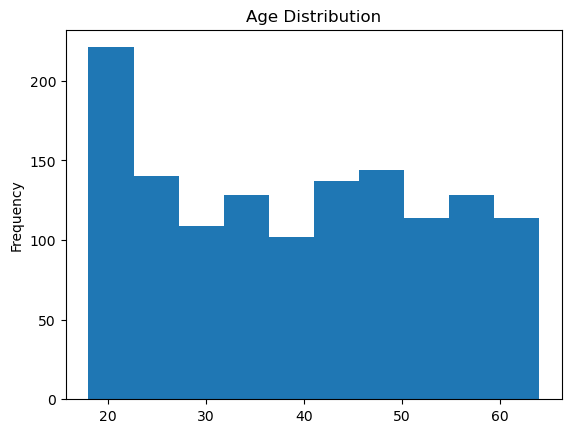

In [23]:
insurance_data1['age'].plot(kind = 'hist')
plt.title("Age Distribution")
plt.show()

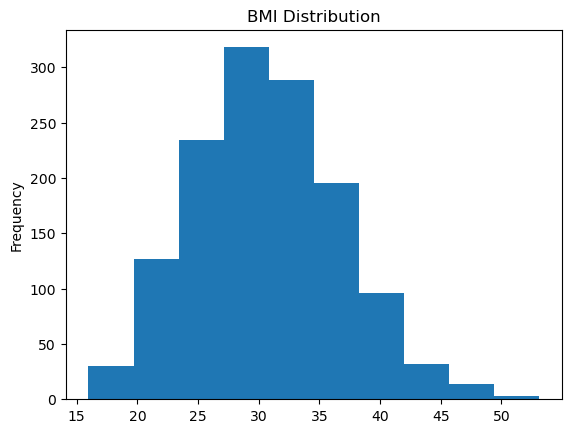

In [24]:
insurance_data1['bmi'].plot(kind = 'hist')
plt.title("BMI Distribution")
plt.show()

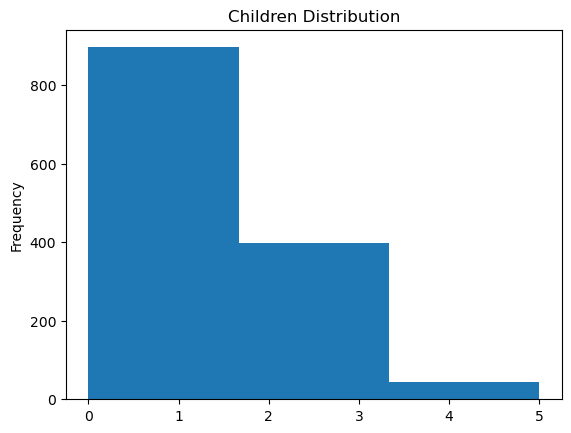

In [25]:
insurance_data1['children'].plot(kind = 'hist', bins = 3)
plt.title("Children Distribution")
plt.show()

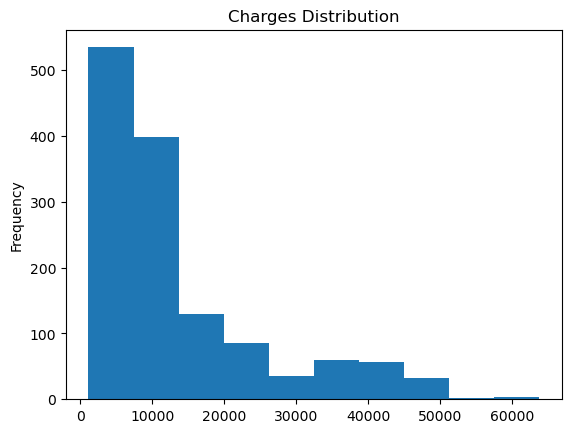

In [27]:
insurance_data1['charges'].plot(kind = 'hist')
plt.title("Charges Distribution")
plt.show()

### Bar Graph - Categorical Columns: 

<Axes: xlabel='children'>

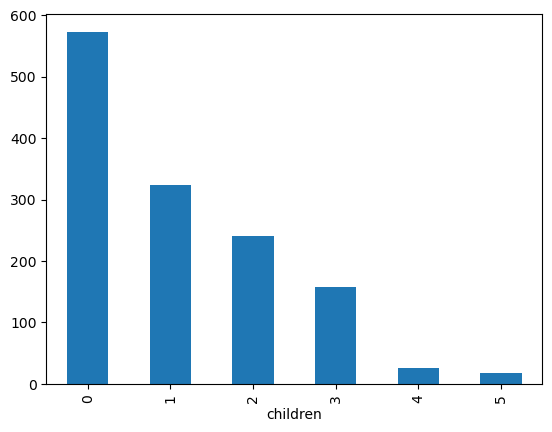

In [28]:
insurance_data1['children'].value_counts().plot(kind='bar')

<Axes: xlabel='sex'>

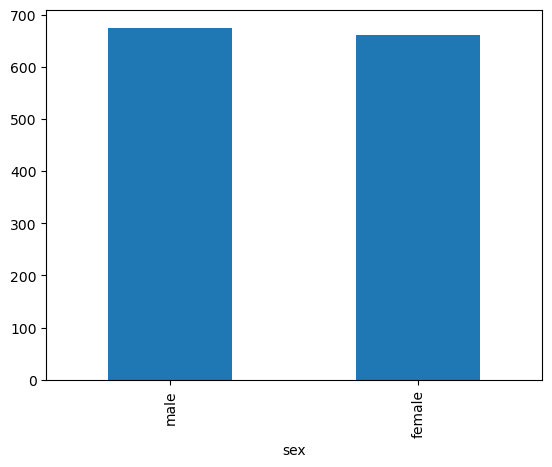

In [29]:
insurance_data1['sex'].value_counts().plot(kind='bar')

<Axes: xlabel='region'>

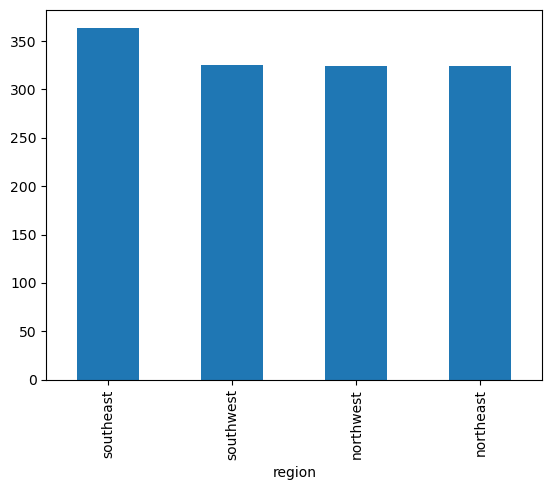

In [30]:
insurance_data1['region'].value_counts().plot(kind='bar')

<Axes: xlabel='smoker'>

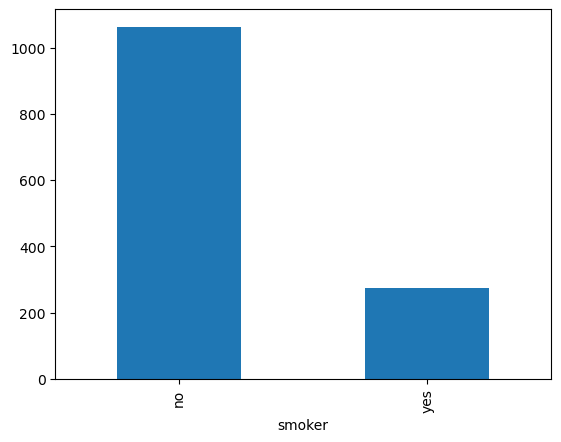

In [31]:
insurance_data1['smoker'].value_counts().plot(kind='bar')

### Box Plot - Numeric Columns: 

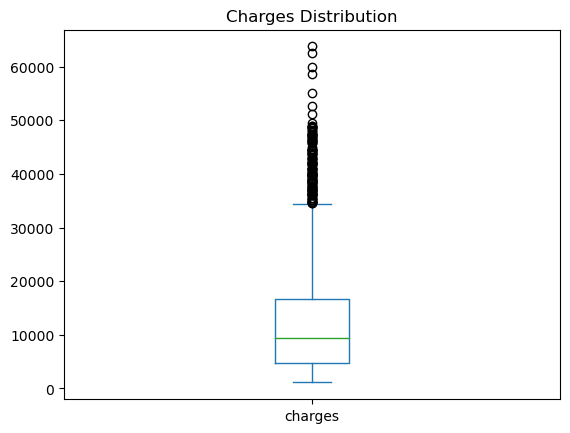

In [32]:
insurance_data1['charges'].plot(kind = 'box')
plt.title("Charges Distribution")
plt.show()

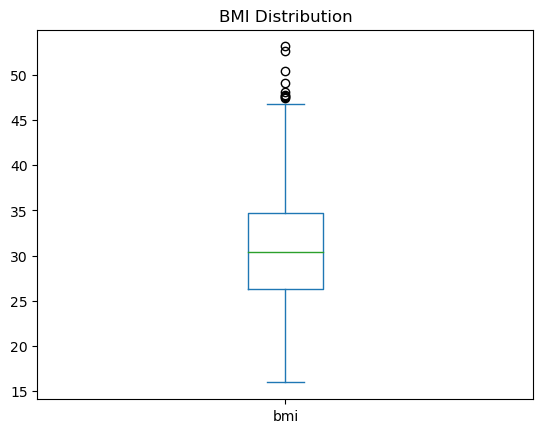

In [33]:
insurance_data1['bmi'].plot(kind = 'box')
plt.title("BMI Distribution")
plt.show()

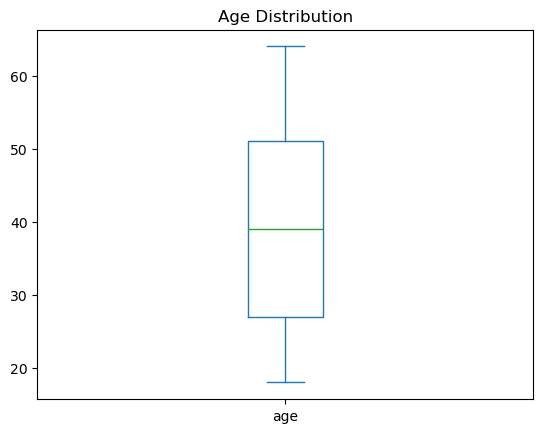

In [34]:
insurance_data1['age'].plot(kind = 'box')
plt.title("Age Distribution")
plt.show()

### Pie Chart - Region 

In [35]:
region_count = insurance_data1["region"].value_counts()
region_count

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

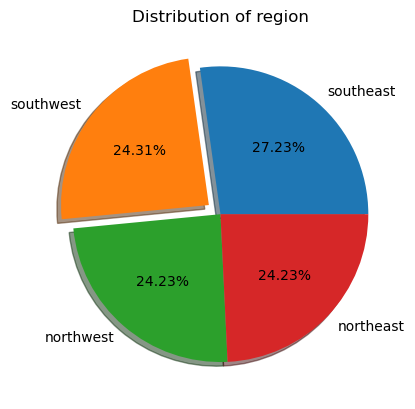

In [37]:
plt.pie(labels = region_count.index,
       x = region_count.values,
       shadow = True,
       autopct = '%.2f%%',
       explode = (0, 0.1, 0, 0))
plt.title("Distribution of region")
plt.show()

### Correlation Matrix: 

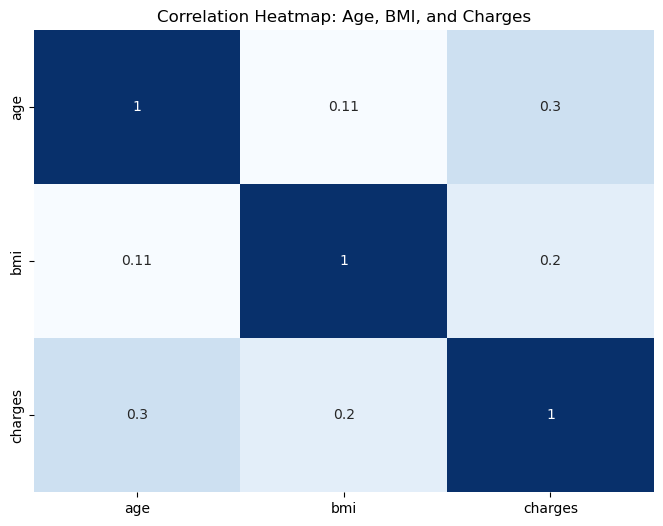

In [40]:
corr_data = insurance_data1[["age", "bmi", "charges"]].corr()

plt.figure(figsize=(8, 6)) # the figure size
sns.heatmap(round(corr_data, 2), annot=True, cmap="Blues", cbar=False)
plt.title("Correlation Heatmap: Age, BMI, and Charges")
plt.show()

### Scatter Plot: 

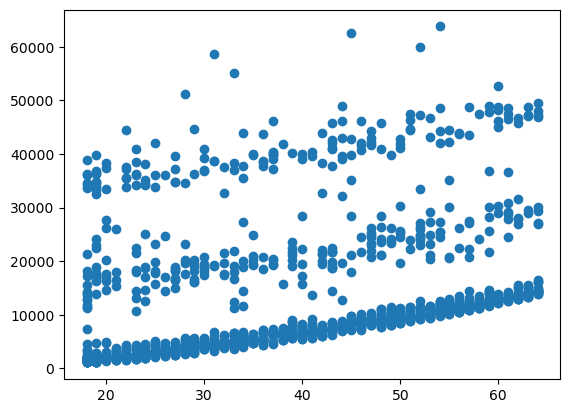

In [41]:
plt.scatter(data = insurance_data1, x = 'age', y = 'charges')

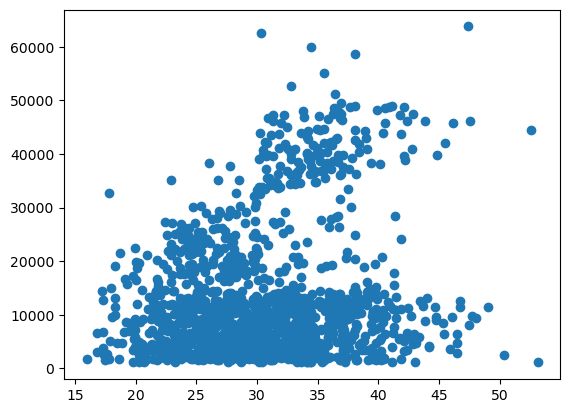

In [42]:
plt.scatter(data = insurance_data1, x = 'bmi', y = 'charges')

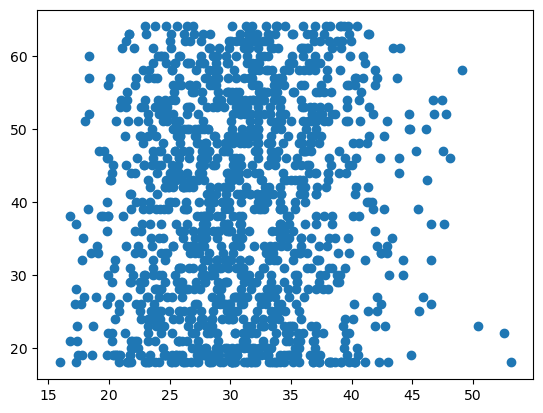

In [43]:
plt.scatter(data = insurance_data1, x = 'bmi', y = 'age')

### Insurance Cost for Smoker and Non Smoker: 

In [44]:
smoker_df = insurance_data1.groupby("smoker")["charges"].mean().reset_index()
smoker_df

,smoker,charges
0,no,8440.660307
1,yes,32050.231832


<Axes: xlabel='smoker'>

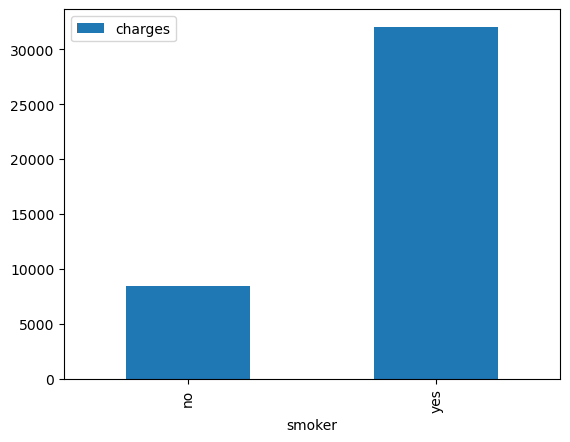

In [45]:
smoker_df.plot(kind = 'bar', x = 'smoker', y = 'charges')

### Insurance cost for Male and Female: 

In [46]:
gender_df = insurance_data1.groupby("sex")["charges"].mean().reset_index()
gender_df

,sex,charges
0,female,12569.578844
1,male,13974.998864


<Axes: xlabel='sex'>

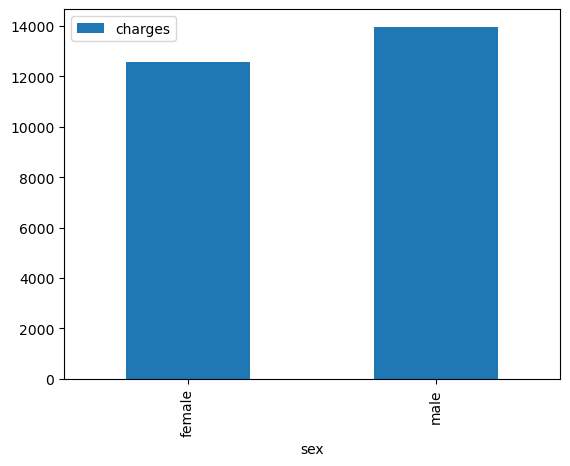

In [47]:
gender_df.plot(kind = 'bar', x = 'sex', y = 'charges')

### Region wise Insurance cost: 

In [48]:
region_df = insurance_data1.groupby("region")["charges"].mean().reset_index()
region_df

,region,charges
0,northeast,13406.384516
1,northwest,12450.840844
2,southeast,14735.411438
3,southwest,12346.937377


<Axes: xlabel='region'>

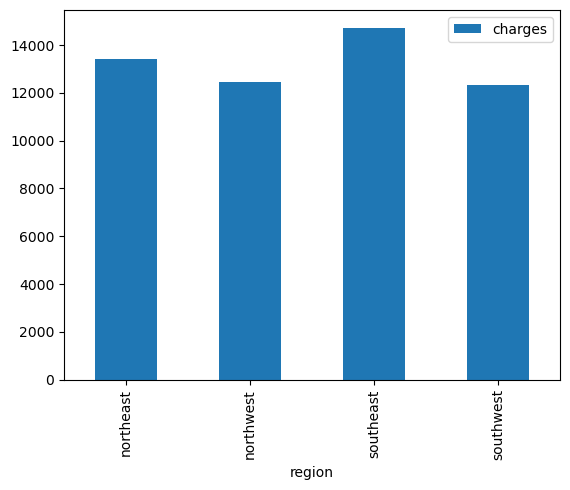

In [49]:
region_df.plot(kind = 'bar', x = 'region', y = 'charges')

### Region wise BMI: 

In [50]:
region_bmi_df = insurance_data1.groupby("region")["bmi"].mean().reset_index()
region_bmi_df

,region,bmi
0,northeast,29.173503
1,northwest,29.195494
2,southeast,33.355989
3,southwest,30.596615


<Axes: xlabel='region'>

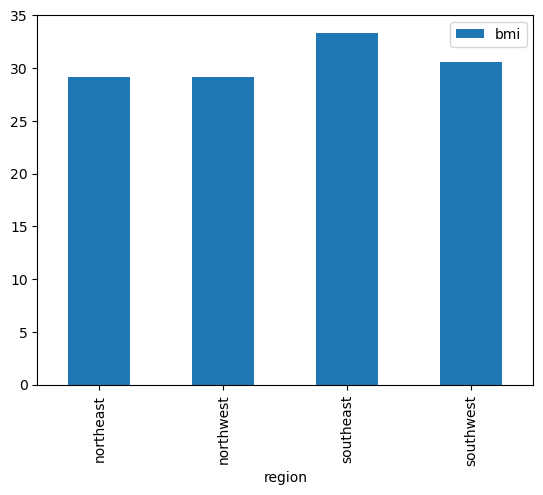

In [51]:
region_bmi_df.plot(kind = 'bar', x = 'region', y = 'bmi')

## Machine Learning Model 

### Label Encoding:

In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [53]:
insurance_data1['sex'] = le.fit_transform(insurance_data1['sex'])
insurance_data1['smoker'] = le.fit_transform(insurance_data1['smoker'])
insurance_data1['region'] = le.fit_transform(insurance_data1['region'])

C:\Users\lekha\AppData\Local\Temp\ipykernel_17680\1414544026.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_data1['sex'] = le.fit_transform(insurance_data1['sex'])
C:\Users\lekha\AppData\Local\Temp\ipykernel_17680\1414544026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  insurance_data1['smoker'] = le.fit_transform(insurance_data1['smoker'])
C:\Users\lekha\AppData\Local\Temp\ipykernel_17680\1414544026.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [54]:
insurance_data1.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [55]:
### X - independent Variable
### y - dependent Variable

In [56]:
X = insurance_data1.drop(columns =["charges"], axis=1)
y = insurance_data1["charges"]

In [57]:
X

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1
1334,18,0,31.920,0,0,0
1335,18,0,36.850,0,0,2
1336,21,0,25.800,0,0,3


In [58]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1337, dtype: float64

## Split the data into training and testing:

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42, shuffle=True)

## check the shape of splitting data
print(f"the shape of X train: {X_train.shape}")
print(f"the shape of y train: {y_train.shape}")

print("*"*30)

print(f"the shape of X test: {X_test.shape}")
print(f"the shape of X test: {X_test.shape}")

the shape of X train: (1069, 6)
the shape of y train: (1069,)
******************************
the shape of X test: (268, 6)
the shape of X test: (268, 6)


### Features Scaling: 

In [61]:
X

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1
1334,18,0,31.920,0,0,0
1335,18,0,36.850,0,0,2
1336,21,0,25.800,0,0,3


In [62]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [63]:
X['age'] = std_scaler.fit_transform(np.array(X['age']).reshape(-1, 1))
X['bmi'] = std_scaler.fit_transform(np.array(X['bmi']).reshape(-1, 1))
X['children'] = std_scaler.fit_transform(np.array(X['children']).reshape(-1, 1))

In [64]:
X

,age,sex,bmi,children,smoker,region
0,-1.440418,0,-0.453160,-0.909234,1,3
1,-1.511647,1,0.509422,-0.079442,0,2
2,-0.799350,1,0.383155,1.580143,0,2
3,-0.443201,1,-1.305052,-0.909234,0,1
4,-0.514431,1,-0.292456,-0.909234,0,1
...,...,...,...,...,...,...
1333,0.767704,1,0.050269,1.580143,0,1
1334,-1.511647,0,0.206053,-0.909234,0,0
1335,-1.511647,0,1.014490,-0.909234,0,2
1336,-1.297958,0,-0.797524,-0.909234,0,3


## Linear Regression Model Development: 

In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
linear_reg_model = LinearRegression()

In [68]:
linear_reg_model.fit(X_train, y_train)

LinearRegression()

### Cross Validation :

In [69]:
from sklearn.model_selection import cross_val_score, cross_validate

In [70]:
result = cross_validate(linear_reg_model, X, y, cv = 5, return_train_score= True, scoring= 'r2')
result

{'fit_time': array([0.01011801, 0.00419688, 0.00563288, 0.00545287, 0.00858617]),
 'score_time': array([0.00693274, 0.00305867, 0.00333381, 0.00286841, 0.00217509]),
 'test_score': array([0.76123487, 0.70840689, 0.77720769, 0.73365562, 0.7551376 ]),
 'train_score': array([0.74737531, 0.75930033, 0.74326474, 0.75468466, 0.74915469])}

In [71]:
train_acc = result['train_score'].mean() * 100
print('Training Accuracy = ', round(train_acc, 2), '%')

Training Accuracy =  75.08 %


In [72]:
test_acc = result['test_score'].mean() * 100
print('Testing Accuracy = ', round(test_acc,2), '%')

Testing Accuracy =  74.71 %


###  Multiple models:

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [75]:
models = []
models.append(("Linear Regression", LinearRegression()))
models.append(("Knn", KNeighborsRegressor()))
models.append(("Decision Tree", DecisionTreeRegressor()))
models.append(("Random Forest", RandomForestRegressor()))
for model in models:
    result = cross_validate(model[1], X, y, cv = 5, return_train_score= True, scoring= 'r2')
    print(model[0])
    train_acc = round((result["train_score"].mean()) * 100, 2)
    test_acc = round((result["test_score"].mean()) * 100, 2)
    print(f'Train R2 score : {train_acc}')
    print(f'Test R2 score : {test_acc}')
    print('\n')

Linear Regression
Train R2 score : 75.08
Test R2 score : 74.71


Knn
Train R2 score : 81.44
Test R2 score : 68.87


Decision Tree
Train R2 score : 99.9
Test R2 score : 71.16


Random Forest
Train R2 score : 97.62
Test R2 score : 83.6




### Random Forest Hyperparameter Tuning Using RandomSearch 

In [76]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [77]:
params = {
    'n_estimators': [100, 200, 300], # Number of trees in random forest
    'max_depth': [None, 5, 10], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required at each leaf node
    'bootstrap': [True, False] # Method of selecting samples for training each tree
}

## Tunning using random search
random_search = RandomizedSearchCV(
    param_distributions=params, # Specify the parameter distributions to sample from
    estimator=RandomForestRegressor (), # Specify the estimator to use
    cv=5, # Number of cross-validation folds
    return_train_score=True, # Include training scores in the results
    scoring= 'r2', # Scoring metric to optimize
    n_jobs=-1 # Use all available CPU cores for parallel computation
)

In [79]:
random_search.fit(X, y)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   return_train_score=True, scoring='r2')

In [80]:
random_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_depth': 5,
 'bootstrap': True}

In [81]:
random_search.cv_results_['mean_train_score'].mean() * 100

92.72076062511351

In [82]:
random_search.cv_results_['mean_test_score'].mean() * 100

82.20464430044956

In [83]:
RF = RandomForestRegressor(n_estimators = 100,
                          min_samples_split = 5,
                          min_samples_leaf = 2,
                          max_depth = 5,
                          bootstrap= True)

In [84]:
RF.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=5)

In [85]:
from sklearn.metrics import r2_score

In [86]:
predicted_train_data = RF.predict(X_train)
train_score = r2_score(y_true=y_train, y_pred=predicted_train_data)
predicted_test_data = RF.predict(X_test)
test_score = r2_score(y_true=y_test, y_pred=predicted_test_data)
print(f"R-squared (R^2) for Training Data Using Random Forest: {round(train_score, 2)*100} %")
print(f"R-squared (R^2) for Testing Data Using Random Forest: {round(test_score, 2)*100} %")

R-squared (R^2) for Training Data Using Random Forest: 88.0 %
R-squared (R^2) for Testing Data Using Random Forest: 90.0 %


### Create a Scatter Plot with a Regression Line 

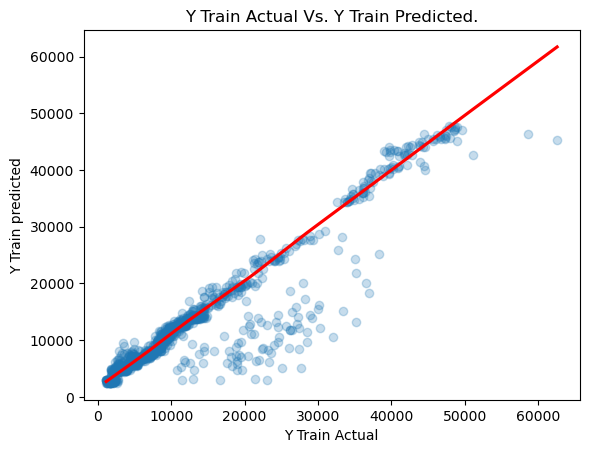

In [88]:
sns.regplot(x = y_train, y = predicted_train_data,
          lowess = True, ## Add a locally weighted scatterplot smoothing line
          line_kws = {'color': 'red'}, ## the color of the Regression line
          scatter_kws = {'alpha': 0.25}) ## the transparency of the scatter points


plt.title("Y TRAIN ACTUAL VS. Y TRAIN PREDICTED.".title())
plt.xlabel("Y Train Actual")
plt.ylabel("Y Train predicted")
plt.show()

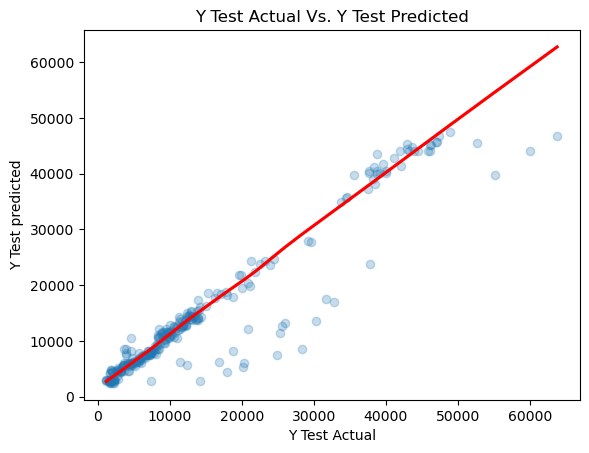

In [92]:
sns.regplot(
    x = y_test, y = predicted_test_data,
    lowess = True, ## Add a locally weighted scatterplot smoothing line
    line_kws = {'color': 'red'}, ## the color of the Regression line
    scatter_kws = {'alpha': 0.25}) ## the transparency of the scatter points

plt.title("Y TEST ACTUAL VS. Y TEST PREDICTED".title())
plt.xlabel("Y Test Actual")
plt.ylabel("Y Test predicted")
plt.show()